In [1]:
from IPython.core.display import HTML
HTML("""
<style>

h1 {
    background-color: SteelBlue;
    color: white;
    padding: 15px 15px;
    text-align: center;
    font-family: Arial, Helvetica, sans-serif;
    border-radius:10px 10px;
}

h2 {
    background-color: CadetBlue;
    color: white;
    padding: 10px 10px;
    text-align: center;
    font-family: Arial, Helvetica, sans-serif
    border-radius:10px 10px;
}


</style>
""")

<h1><font color=white>Introduction</font></h1>


Hello everyone, in this kernel it will be presented a study of a famous dataset "Hotel booking demand", it contains informations of a City Hotel and a Resort Hotel in period of July 2015 to August 2017, both hotels are located in Portugal, City Hotel in Lisboa and Resort Hotel in Algarve, a coastal town.

The most diverse characteristics of a City Hotel and Resort Hotel will be analyzed in order to understand a little about what these hotels are, their prices, their customers etc, after will be developed a machine learning model capable of predicting cancellations, based on the most relevant characteristics.<br><br>

<b>keywords:</b> hotel, EDA, machine Learning, data, classification, vizualization, features, prices, guests, cancelation, pipeline.<br><br>


<font size="4"><b> Contents</b></font><br>

* <b>Data Prepearing</b><br>
    Dealing with missing values, unexpected values, etc...<br><br>
* <b>Exploratory Data Analysis</b><br>  
    * Prices
    * Guests
    * Cancelations<br> <br>
* <b>Machine Learning Model</b><br>
    * Preprocessing
        - Encoding
        - Dimnensionality Reduction
        - Standardization
    * Pipelines
        - Logistic Regression
        - Random Forest
        - XGBosst       
    * Holdout Validation(Split Test-Train)
    * Cross Validation k-Fold
    * ROC, AUC            
    * Hyperparamters Tunning<br> <br>        
* <b>Conclusion</b><br>
    Insights about Business, EDA, Machine Learning models<br><br> 
    
    
To learn more about what each variable means, go to the [original datase](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)

In [2]:
### Data Analisy Libraries ###
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import pandas as pd

### Deploy ###
import pickle


### Machine Learning Libraries ###
from sklearn.model_selection import cross_val_score, cross_val_predict, GridSearchCV, KFold, cross_validate
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, MinMaxScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, recall_score, precision_score, mean_squared_error, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc 
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, chi2, SelectFromModel, VarianceThreshold, SelectPercentile
from sklearn import set_config

### Complementary Libraries ###
import time
import warnings
warnings.filterwarnings("ignore")

set_config(display='diagram')

import os

for dirname, _, filenames in os.walk('C:\\Users\Alysson\Documents\Projects\Hotel Booking'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

C:\Users\Alysson\Documents\Projects\Hotel Booking\handler.py
C:\Users\Alysson\Documents\Projects\Hotel Booking\Hotel Booking.ipynb
C:\Users\Alysson\Documents\Projects\Hotel Booking\hotel.jpg
C:\Users\Alysson\Documents\Projects\Hotel Booking\hotel_booking.pkl
C:\Users\Alysson\Documents\Projects\Hotel Booking\hotel_bookings.csv
C:\Users\Alysson\Documents\Projects\Hotel Booking\.ipynb_checkpoints\Credit Risk-checkpoint.ipynb
C:\Users\Alysson\Documents\Projects\Hotel Booking\.ipynb_checkpoints\Hotel Booking-checkpoint.ipynb


In [3]:
pd.options.display.float_format = '{:,.2f}'.format
pd.set_option("display.max_columns", 35)
sns.set_style("whitegrid")

data =  pd.read_csv('C:\\Users\Alysson\Documents\Projects\Hotel Booking\hotel_bookings.csv')

# Data Preparing

Some common problems are found after loading data, such as unexpected values, missing values, incomplete values, this needs to be corrected, in addition some configurations that help the organization and visualization of the code are welcome.

In [4]:
#verifying dataset disposal by last five records
data.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.00,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.00,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.00,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.00,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.00,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.00,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.00,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,0.00,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.00,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [5]:
data['reservation_status_date'] = pd.to_datetime(data['reservation_status_date'], format="%Y-%m-%d").dt.year

In [6]:
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.00,NaN,0,Transient,75.00,0,0,Check-Out,2015
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015


In [7]:
#verifying columns, null values, variable types... 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [8]:
#count of null values
data.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [13]:
#statistical summary
data.describe().Tstyle.bar(subset=['mean'],color='#606ff2').background_gradient(subset=['std'], cmap='PuBu').background_gradient(subset=['50%'], cmap='PuBu')

AttributeError: 'DataFrame' object has no attribute 'Tstyle'

In [14]:
#renaming columns for better vizualization
data.columns = ['Hotel', 'Canceled', 'Lead Time', 'Arriving Year', 'Arriving Month', 'Arriving Week','Arriving Day', 'Weekend Stay',
              'Week Stay', 'Adults', 'Children', 'Babies', 'Meal','Country', 'Segment', 'Dist Channel','Repeat Guest', 'Prev Cancel',
              'Prev Book', 'Book Room Type','Assign Room Type', 'Change Booking', 'Deposit Type', 'Agent','Company','Waiting Days', 
              'Customer Type', 'ADR','Park Space', 'Special Request','Reservation Status', 'Reservation Date']

In [15]:
#replacing missing values
nan_replacements = {"Children": 0,"Country": "Unknown", "Agent": 0, "Company": 0}
data = data.fillna(nan_replacements)

In [16]:
#fixing data type
data = data.astype({"Children": int, "Agent": int, "Company": int})

In [17]:
#removing zero guests possibility
no_guest = ((data['Children'] == 0) & (data['Adults'] == 0) & (data['Babies'] == 0))
data = data[~no_guest]

In [18]:
#removing negative values for transactions possibility
negative_ADR = (data["ADR"] < 0)
data = data[~negative_ADR]
negative_ADR

0         False
1         False
2         False
3         False
4         False
          ...  
119385    False
119386    False
119387    False
119388    False
119389    False
Name: ADR, Length: 119210, dtype: bool

In [19]:
#replaceing some values for easy vizualization
data['Canceled'].replace(0, "No", inplace=True)
data['Canceled'].replace(1, "Yes", inplace=True)

In [20]:
#same meaning values according to dictionary source
data['Meal'].replace("Undefined", "SC", inplace=True)

In [21]:
#these new columns will help our analysis further on
data["ADR per person"] = data["ADR"] / (data["Adults"] + data["Children"])
data["People"] = (data["Adults"] + data["Children"] + data["Babies"])
data['Kids'] = data['Children'] + data['Babies']
data['Days Stay'] = data['Weekend Stay'] + data['Week Stay']

# Exploratory Data Analysis

In this EDA the most relevant characteristics for a hotel business will be analyzed, which are prices, guests and cancellations.

<h2>Prices</h2>

  * How many books were recorded?
  * How much people pay for a night?
  * How prices vary over year?
  * How do the prices vary by Room Type?
  * How do the prices vary by Market Segment?

In [22]:
# sum all values of a list and return the percentage and sum
def func(pct, allvalues): 
    absolute = int(pct / 100.*np.sum(allvalues)) 
    return "{:.2f}%\n\n{:d}".format(pct, absolute) 

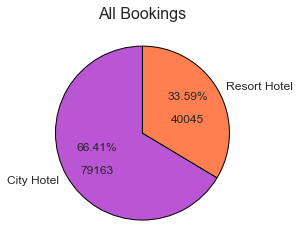

In [23]:
# sum all values of a list and return the percentage and sum
def func(pct, allvalues): 
    absolute = int(pct / 100.*np.sum(allvalues)) 
    return "{:.2f}%\n\n{:d}".format(pct, absolute) 


lt.subplots(figsize=(4,4))

labels = data['Hotel'].value_counts().index.tolist()
sizes = data['Hotel'].value_counts().tolist()

plt.pie(sizes, labels=labels, colors=['MediumOrchid', 'Coral'], autopct = lambda pct: func(pct, sizes), startangle=90, 
        wedgeprops = { 'linewidth' : 1, 'edgecolor' : "black" }, textprops={'fontsize': 12})
plt.title("All Bookings", fontsize=16)
plt.show()

<font size="2"><b>Note:</b> This pie chart contains canceled and non-canceled Bookings.</font>

In [24]:
#Separing Canceled and Non-Canceled
data2 = data[data['Canceled']=='No']

#Separing Canceled and Non-Canceled Costurmer by Hotel
rh = data.loc[(data["Hotel"] == "Resort Hotel") & (data["Canceled"] == 'No')]
ch = data.loc[(data["Hotel"] == "City Hotel") & (data["Canceled"] == 'No')]

In [25]:
rh_month = rh.groupby(['Arriving Month'])['ADR per person'].mean().reset_index()
ch_month = ch.groupby(['Arriving Month'])['ADR per person'].mean().reset_index()

mean_prices_month = rh_month.merge(ch_month, on = 'Arriving Month')
mean_prices_month.columns = ['Arriving Month', 'Resort Hotel mean price (EUR)', 'City Hotel mean price (EUR)']

#There is no native function that sorts columns by month written in full, we will have to either develop code that does this or import a library that contains this code.

In [26]:
!pip install sort-dataframeby-monthorweek
!pip install sorted-months-weekdays

In [27]:
import sort_dataframeby_monthorweek as sd

def sort_month(df, column_name):
    return sd.Sort_Dataframeby_Month(df, column_name)

In [28]:
mean_prices_month = sort_month(mean_prices_month, 'Arriving Month')
mean_prices_month

,Arriving Month,Resort Hotel mean price (EUR),City Hotel mean price (EUR)
0,January,31.17,51.28
1,February,30.85,50.95
2,March,34.12,52.48
3,April,43.73,58.72
4,May,42.25,69.99
5,June,56.35,66.34
6,July,70.26,57.26
7,August,83.32,57.77
8,September,50.37,67.04
9,October,35.14,61.80


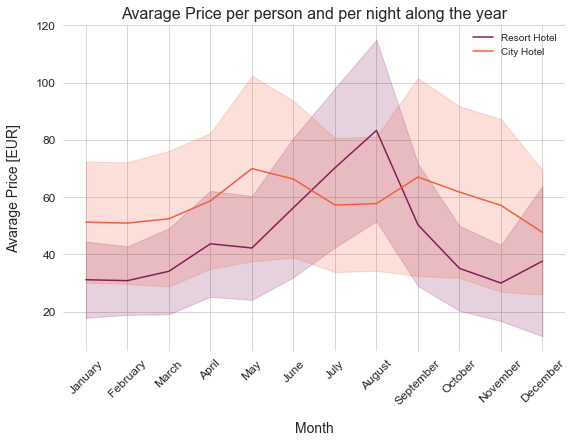

Max and Min ADR per person recorded on City Hotel: 510.00 €, 0.00 €
Max and Min ADR per person recorded on Resort Hotel: 254.00 €, 0.00 €


In [29]:
data2 = sort_month(data2,'Arriving Month')
plt.subplots(figsize=(9,6))
sns.lineplot(data=data2, x="Arriving Month", y="ADR per person", hue="Hotel", ci="sd", palette= 'rocket')
plt.title("Avarage Price per person and per night along the year", fontsize=16)
plt.xlabel("Month", labelpad=15, fontsize=14)
plt.ylabel("Avarage Price [EUR]", labelpad=15, fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(ncol=1, loc="upper right", frameon=False)
sns.despine(left=True, bottom=True)
plt.show()

print("""Max and Min ADR per person recorded on City Hotel: {:.2f} €, {:.2f} €""".format(ch['ADR per person'].max(), ch['ADR per person'].min()))
print("""Max and Min ADR per person recorded on Resort Hotel: {:.2f} €, {:.2f} €""".format(rh['ADR per person'].max(), rh['ADR per person'].min()))

The demand for City Hotel is significantly higher than Resort Hotel most of the year.<br>
City Hotel have higher average prices than Resort Hotel along the year, except in July and August (late spring/early summer) when prices are higher.<br>
City Hotel has more stabled avarage prices (does not have these huge peaks as Resort Hotel).<br>

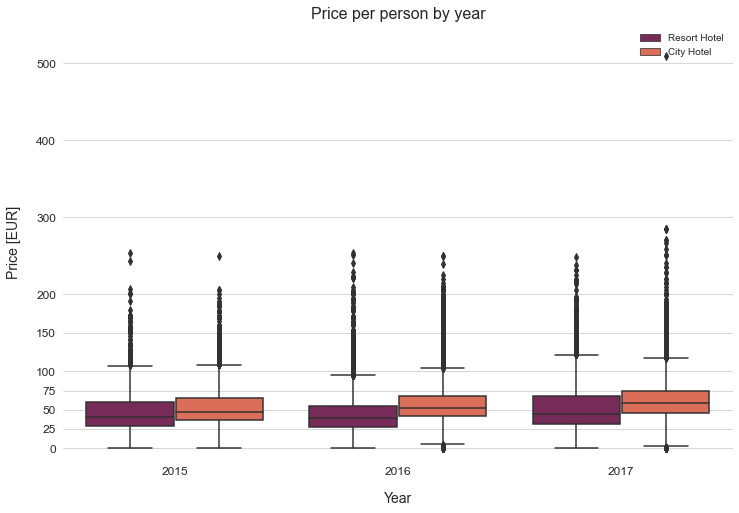

In [30]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=data2, x="Arriving Year", y="ADR per person", hue="Hotel", palette= 'rocket')
plt.title("Price per person by year", fontsize=16)
plt.xlabel("Year", labelpad=15, fontsize=14)
plt.ylabel("Price [EUR]", labelpad=15, fontsize=14)
plt.xticks(fontsize=12)
plt.yticks([0,25,50,75, 100,150,200,300,400,500],fontsize=12)
plt.legend(ncol=1, loc="upper right", frameon=False)
plt.ylim(-15, 550)
sns.despine(left=True, bottom=True)
plt.show()

<font size="2"><b>Note:</b> Only the year 2016 has recorded in every month, part of thoses charts were generated only with an average of two years.</font><br><br>

City Hotel has higher average prices per year compared to Resort Hotel ( same results seen on last chart).<br>
There is a most common/popular price around 40€ and 60€ per person per night.<br> 
Prices per person equal to zero it's not so unusual, probably is a sweepstakes or a super-promotion with all paid packages.

In [31]:
room_spent = data2[["Hotel", "Book Room Type", "ADR per person",'People','Segment']].sort_values("Book Room Type")
rh_room = rh.groupby(['Book Room Type'])['ADR per person'].mean().reset_index()
ch_room = ch.groupby(['Book Room Type'])['ADR per person'].mean().reset_index()

mean_prices_room= pd.concat([rh_room,ch_room],axis=1)
mean_prices_room.columns = ['Room', 'Resort Hotel mean price (EUR)','Room2', 'City Hotel mean price (EUR)']
mean_prices_room.drop('Room2',axis=1,inplace=True)
mean_prices_room

,Room,Resort Hotel mean price (EUR),City Hotel mean price (EUR)
0,A,43.19,58.49
1,B,52.33,43.60
2,C,50.55,46.56
3,D,50.77,62.77
4,E,55.76,74.55
5,F,63.38,55.61
6,G,54.71,61.59
7,H,52.73,NaN
8,L,76.38,NaN


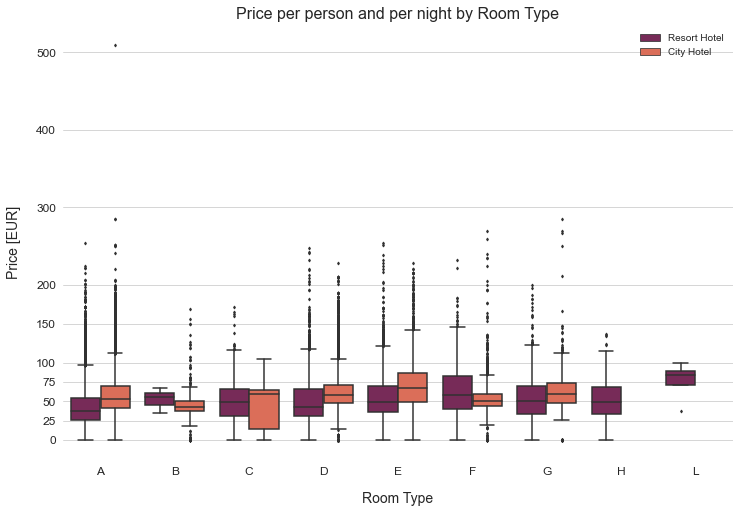

In [32]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=room_spent, x="Book Room Type", y="ADR per person", hue="Hotel", palette='rocket', fliersize=2)
plt.title("Price per person and per night by Room Type", fontsize=16)
plt.xlabel("Room Type", labelpad=15, fontsize=14)
plt.ylabel("Price [EUR]", labelpad=15, fontsize=14)
plt.xticks(fontsize=12)
plt.yticks([0,25,50,75, 100,150,200,300,400,500],fontsize=12)
plt.legend(ncol=1, loc="upper right", frameon=False)
sns.despine(left=True, bottom=True)
plt.show()

City Hotel Room "B" have de lowest avarage price and Room "E" the highest avarage price.<br> 
Resort Hotel Room "A" have de lowest avarage price and Room "L" the highest avarage price.<br> 
There is no Room "H" and "L" for Resort Hotel.<br> 
Although the rooms have the same name, they do not necessarily have the same characteristics ( the dataset does not provide this information).

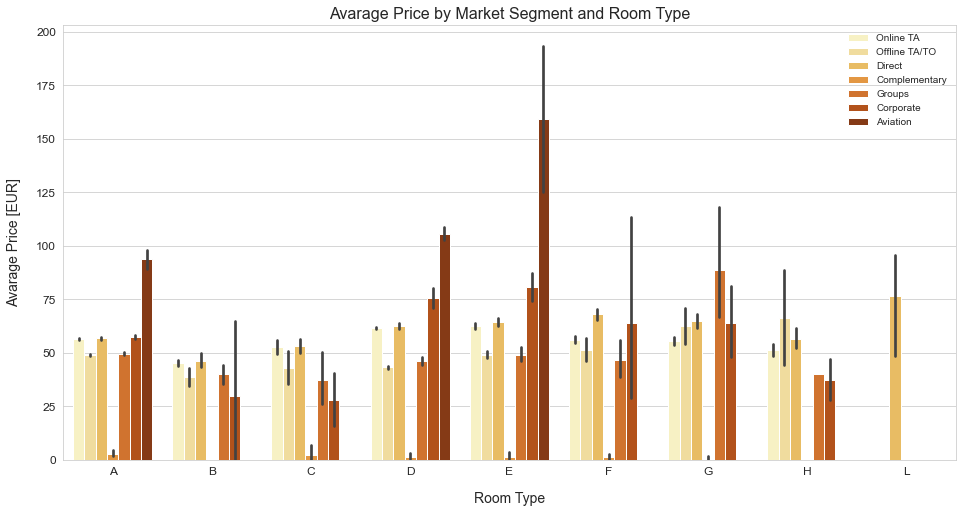

In [33]:
plt.figure(figsize=(16,8))
sns.barplot(data=room_spent, x="Book Room Type", y="ADR per person", hue="Segment", palette="YlOrBr")
plt.title("Avarage Price by Market Segment and Room Type", fontsize=16)
plt.xlabel("Room Type", labelpad=15, fontsize=14)
plt.ylabel("Avarage Price [EUR]", labelpad=15, fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(ncol=1, loc="upper right", frameon=False)
plt.show()

Aviation segment spend more money on avarage, complementary segment spend less money on avarage.

<h2>Guests</h2>

  * Which is the busiest months?
  * Which is the most chosen Room Type by guests?
  * Which is the most chosen Market Segment by guests?
  * How long do people stay at the hotels?
  * How many of the guests are adults, children and babies?
  * How much time people wait until arrive?
  * How mamy people stay on each room?
  * Where guests coming from?

In [34]:
guests=data2.groupby(['Hotel','Arriving Year','Arriving Month']).agg({'Arriving Month':len,'Adults':sum,'Children':sum,'Babies':sum})
guests.columns=['Guests','Adults','Children','Babies']
guests.reset_index(inplace=True)
guests.columns=['Hotel','Arriving Year','Arriving Month','Guests','Adults','Children','Babies']
guests = sort_month(guests,'Arriving Month')
guests.head(10)

,Hotel,Arriving Year,Arriving Month,Guests,Adults,Children,Babies
0,City Hotel,2016,January,926,1518,45,16
1,City Hotel,2017,January,1323,2261,149,13
2,Resort Hotel,2016,January,765,1276,41,6
3,Resort Hotel,2017,January,1101,1786,65,10
4,City Hotel,2016,February,1436,2485,150,13
5,City Hotel,2017,February,1615,2884,174,17
6,Resort Hotel,2016,February,1113,1944,88,14
7,Resort Hotel,2017,February,1195,2122,124,14
8,City Hotel,2016,March,1933,3534,164,13
9,City Hotel,2017,March,2116,3823,85,15


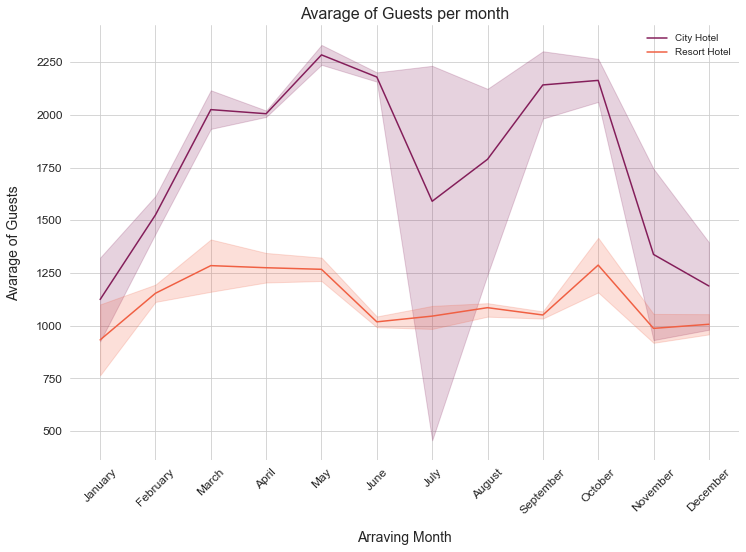

In [35]:
plt.subplots(figsize=(12,8))
sns.lineplot(data=guests, x="Arriving Month", y="Guests", hue="Hotel",palette= 'rocket')
plt.title("Avarage of Guests per month", fontsize=16)
plt.xlabel("Arraving Month", labelpad=15, fontsize=14)
plt.ylabel("Avarage of Guests", labelpad=15, fontsize=14)
plt.xticks(rotation=45,fontsize=12)
plt.yticks(fontsize=12)
plt.legend(ncol=1, loc="upper right", frameon=False)
sns.despine(left=True, bottom=True)
plt.show()

The busiest periods for the City Hotel is between may and october, the busiest periods of the Resort Hotel it's not so clear. July 2015 has a typically lower number of guests compared to other years, a hypothesis, as they refer to the first records may indicate the beginning of the activities of this hotel, or data collection, which requires a period of adaptation.

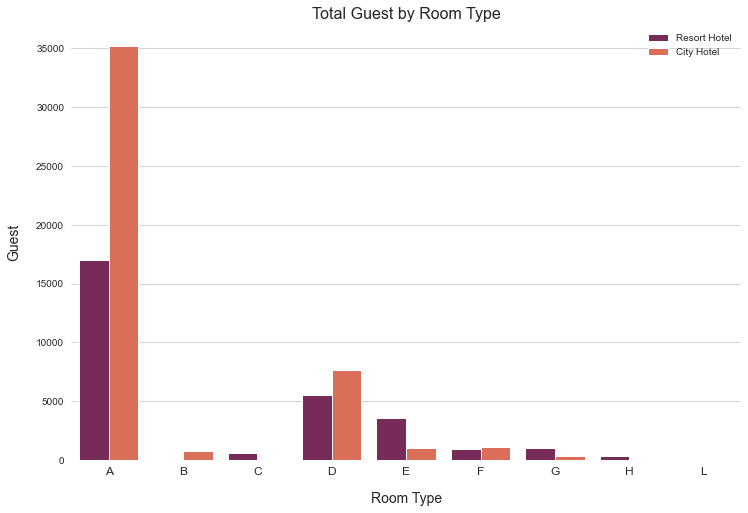

In [36]:
plt.figure(figsize=(12, 8))
sns.countplot(data=room_spent, x="Book Room Type",hue="Hotel", palette= 'rocket')
plt.title("Total Guest by Room Type", fontsize=16)
plt.xlabel("Room Type", labelpad=15, fontsize=14)
plt.ylabel("Guest", labelpad=15, fontsize=14)
plt.xticks(fontsize=12)
plt.legend(ncol=1, loc="upper right", frameon=False)
sns.despine(left=True, bottom=True)
plt.show()

Room "A" is by far the most chosen room by guests. Surprisingly, the others are not often chosen.

In [37]:
segments = data2.groupby(['Hotel', 'Segment']).count().iloc[:,:1]
segments = segments.rename(columns={'Canceled':'Guests'})
segments.reset_index(inplace=True)
segments.sort_values(by='Guests', ascending=False, inplace=True)
segments['Percentage'] = segments['Guests']*100 / segments['Guests'].sum()
segments

,Hotel,Segment,Guests,Percentage
6,City Hotel,Online TA,24192,32.25
12,Resort Hotel,Online TA,11481,15.31
5,City Hotel,Offline TA/TO,9546,12.73
11,Resort Hotel,Offline TA/TO,6334,8.44
9,Resort Hotel,Direct,5632,7.51
3,City Hotel,Direct,5016,6.69
4,City Hotel,Groups,4339,5.78
10,Resort Hotel,Groups,3357,4.48
2,City Hotel,Corporate,2337,3.12
8,Resort Hotel,Corporate,1954,2.60


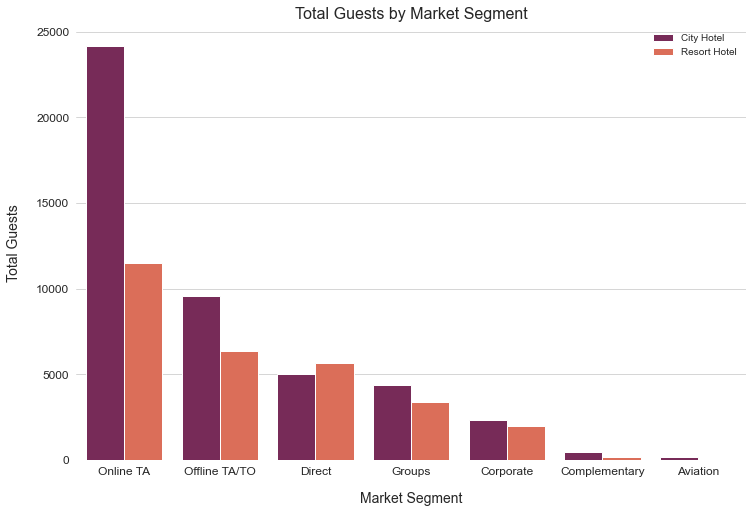

In [38]:
plt.subplots(figsize=(12,8))
sns.barplot(data=segments, x= "Segment",y = "Guests",hue="Hotel", dodge=True, palette= 'rocket', ci=None)
plt.title("Total Guests by Market Segment", fontsize=16)
plt.xlabel("Market Segment", labelpad=15, fontsize=14)
plt.ylabel("Total Guests", labelpad=15, fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(ncol=1, loc="upper right", frameon=False)
sns.despine(left=True, bottom=True)
plt.show()

The world is already quite adapted to the internet, most reservations are made through the internet.
Despite being more profitable, the hotel receives few aviation guests.

In [39]:
guests2=data2.groupby(['Hotel','Book Room Type','Segment']).agg({'Arriving Month':len})
guests2.reset_index(inplace=True)
guests2.rename(columns = {'Arriving Month':'Guests'}, inplace = True)
guests2.columns=['Hotel','Book Room Type','Segment','Guests']
guests2

,Hotel,Book Room Type,Segment,Guests
0,City Hotel,A,Aviation,100
1,City Hotel,A,Complementary,298
2,City Hotel,A,Corporate,2095
3,City Hotel,A,Direct,3215
4,City Hotel,A,Groups,4258
...,...,...,...,...
83,Resort Hotel,H,Direct,126
84,Resort Hotel,H,Groups,1
85,Resort Hotel,H,Offline TA/TO,2
86,Resort Hotel,H,Online TA,223


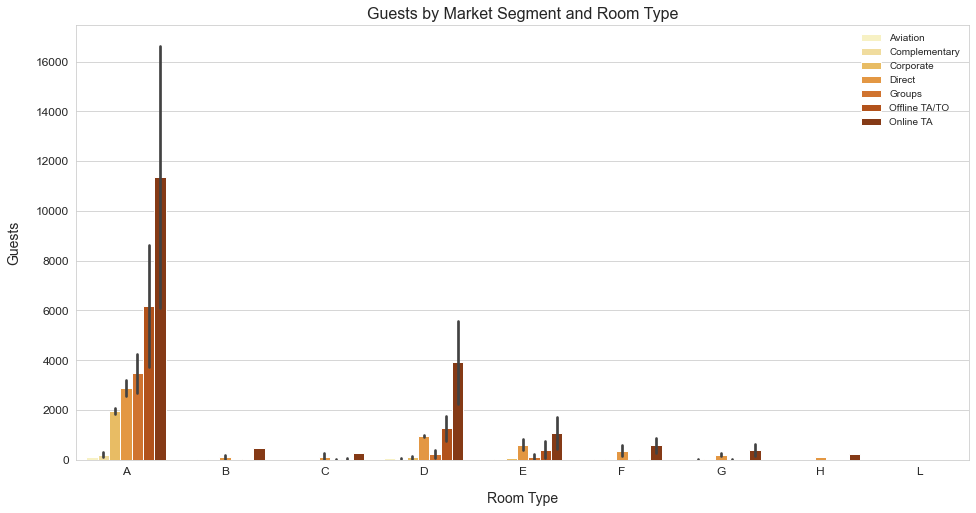

In [40]:
plt.figure(figsize=(16,8))
sns.barplot(data=guests2, x="Book Room Type", y="Guests", hue="Segment", palette="YlOrBr")
plt.title("Guests by Market Segment and Room Type", fontsize=16)
plt.xlabel("Room Type", labelpad=15, fontsize=14)
plt.ylabel("Guests", labelpad=15, fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(ncol=1, loc="upper right", frameon=False)
plt.show()
#guests2.sort_values(by='Guests', ascending=False, inplace=True)
#print(guest2['Guests'].sum())

In [41]:
stay = data2.groupby(['Days Stay', 'Hotel']).agg({'Week Stay':len}).reset_index()
stay = stay.rename(columns={'Week Stay':'Total Days Stay'})
stay['Percentage of Guests'] = stay['Total Days Stay']*100 / stay['Total Days Stay'].sum()
stay.head(10)

,Days Stay,Hotel,Total Days Stay,Percentage of Guests
0,0,City Hotel,251,0.33
1,0,Resort Hotel,371,0.49
2,1,City Hotel,9155,12.21
3,1,Resort Hotel,6579,8.77
4,2,City Hotel,10983,14.64
5,2,Resort Hotel,4488,5.98
6,3,City Hotel,11889,15.85
7,3,Resort Hotel,3828,5.10
8,4,City Hotel,7694,10.26
9,4,Resort Hotel,3321,4.43


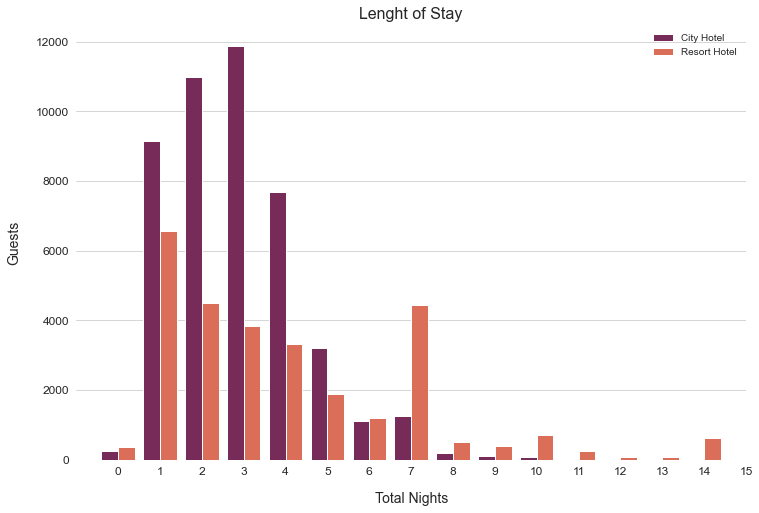

In [42]:
plt.subplots(figsize=(12,8))
sns.barplot(data=stay, x= "Days Stay",y = "Total Days Stay",hue="Hotel",dodge=True, palette= 'rocket')
plt.title("Lenght of Stay", fontsize=16)
plt.xlabel("Total Nights", labelpad=15, fontsize=14)
plt.ylabel("Guests", labelpad=15, fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(ncol=1, loc="upper right", frameon=False)
plt.xlim(-1,15)
sns.despine(left=True, bottom=True)
plt.show()

In City Hotel people use to stay around 1 to 4 days typicaly. In Resort Hotel people use to stay around 1 to 4 days typicaly, also 7 is another option (weekly packages probably).

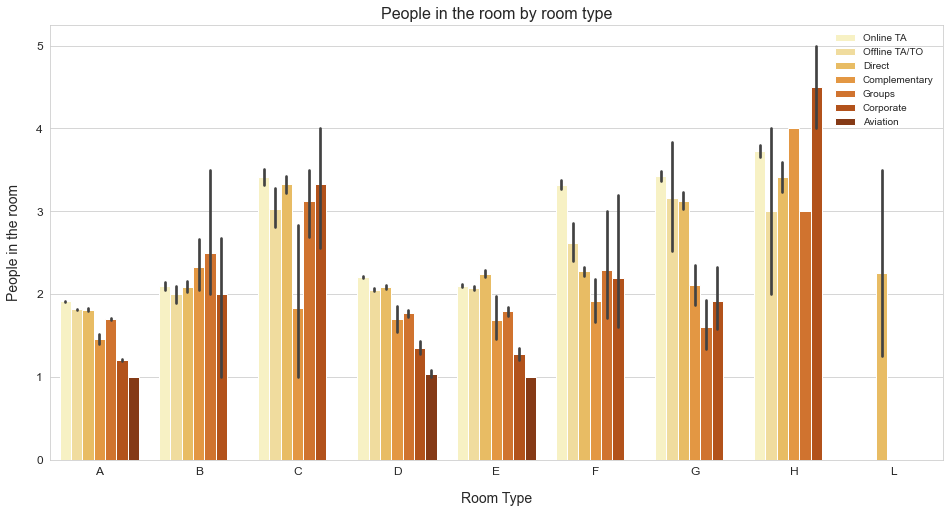

In [43]:
plt.figure(figsize=(16,8))
sns.barplot(data=room_spent, x="Book Room Type", y="People", hue="Segment", palette="YlOrBr")
plt.title("People in the room by room type", fontsize=16)
plt.xlabel("Room Type", labelpad=15, fontsize=14)
plt.ylabel("People in the room", labelpad=15, fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(ncol=1, loc="upper right", frameon=False)
plt.show()

Seems Room "H" is bigger and fancy in other hand Room "A" the smaller and simpliest.

In [44]:
#data2['Kids'] = data2['Children'] + data2['Babies']
display(pd.crosstab(data2['Adults'], data2['Kids'], margins=True, margins_name = 'Total'))

Kids,0,1,2,3,9,10,Total
Adults,,,,,,,
0,0,4,125,10,0,0,139
1,16022,218,110,2,1,0,16353
2,49135,3262,1954,69,0,1,54421
3,3736,283,32,0,0,0,4051
4,44,2,0,0,0,0,46
Total,68937,3769,2221,81,1,1,75010


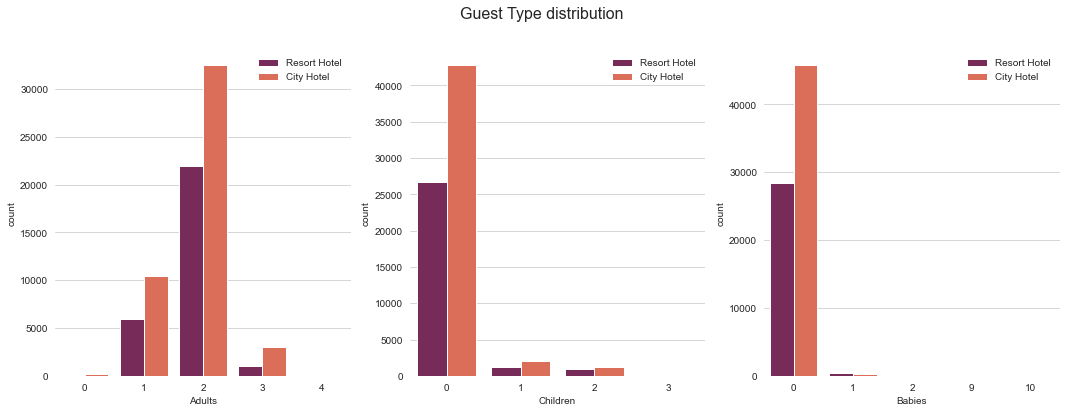

In [45]:
fig, ax = plt.subplots(1,3, figsize=(18,6))
sns.countplot(data=data2, ax=ax[0], x='Adults', hue="Hotel", palette= 'rocket')
sns.countplot(data=data2, ax=ax[1], x='Children', hue="Hotel", palette= 'rocket')
sns.countplot(data=data2, ax=ax[2], x='Babies', hue="Hotel", palette= 'rocket')
ax[0].legend(ncol=1, loc="upper right", frameon=False)
ax[1].legend(ncol=1, loc="upper right", frameon=False)
ax[2].legend(ncol=1, loc="upper right", frameon=False)
fig.suptitle("Guest Type distribution", fontsize=16)
sns.despine(left=True, bottom=True)

The hotel accommodates much more adults than kids( It seems both hotels does not have any great attraction for more to kids). People tend to stay in pairs more often. People tend to stay in adult pairs or alone in most cases.

In [27]:
country_5=data2['Country'].value_counts().iloc[:5]
country_n=data2['Country'].value_counts().iloc[5:].sum()
others=pd.Series( data=country_n, index=["Others"], name ="Country") 
country_resume = pd.concat([country_5, others])

NameError: name 'data2' is not defined

NameError: name 'country_resume' is not defined

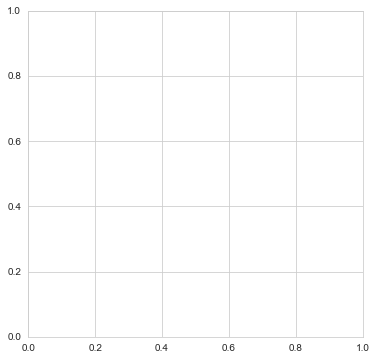

In [28]:
plt.subplots(figsize=(6,6))
labels = country_resume.index.tolist()
sizes = country_resume.tolist()
colors = ['RoyalBlue','SteelBlue', 'LightBlue','SkyBlue','LightSkyBlue','DarkGray' ]
plt.pie(sizes, 
        labels=labels,
        colors=colors,        
        autopct = lambda pct: func(pct, sizes),#autopct= '%1.2f%%',        
        startangle=45, 
        textprops={'fontsize': 12})
plt.title("Country of the Guests", fontsize=16)
plt.show()

print("Total of Countries:", data2['Country'].nunique()-1)

NameError: name 'ch' is not defined

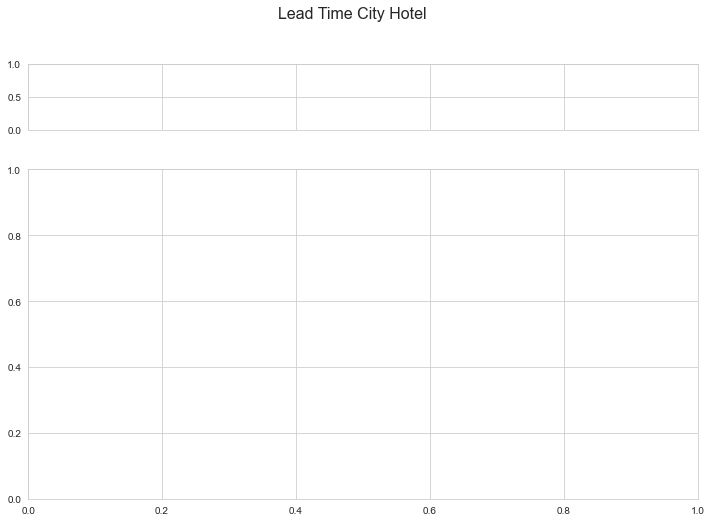

In [29]:
fig, (ax_box, ax_hist) = plt.subplots(2, figsize=(12,8), sharex=True, gridspec_kw = {"height_ratios": (0.2, 1)})
fig.suptitle('Lead Time City Hotel', fontsize=16)
sns.boxplot(ch['Lead Time'], ax=ax_box, linewidth=.5, width=.5,color="DarkMagenta", fliersize=2)
ax_box.set(xlabel='')
sns.histplot(data=ch['Lead Time'], ax=ax_hist, bins=30, kde=True, color="DarkMagenta", edgecolor=".3", linewidth=.5 )
plt.xlabel("Lead Time [Days]", labelpad=15, fontsize=14)
plt.ylabel("Count", labelpad=15, fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

NameError: name 'rh' is not defined

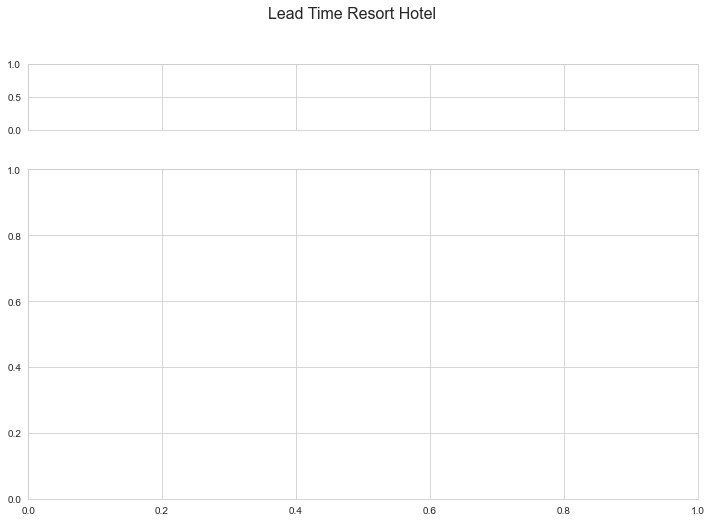

In [30]:
fig, (ax_box, ax_hist) = plt.subplots(2, figsize=(12,8), sharex=True, gridspec_kw = {"height_ratios": (0.2, 1)})

fig.suptitle('Lead Time Resort Hotel', fontsize=16)
sns.boxplot(rh['Lead Time'], ax=ax_box, linewidth=.5, width=.5,color="Coral", fliersize=2)
ax_box.set(xlabel='')
sns.histplot(data=rh['Lead Time'], ax=ax_hist, bins=30, kde=True, color="Coral", edgecolor=".3", linewidth=.5 )
plt.xlabel("Lead Time [Days]", labelpad=15, fontsize=14)
plt.ylabel("Count", labelpad=15, fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Most bookings are made a month befere. Bookings are rarely made one year in advance.

<h2>Cancelations</h2>

  * How many bookings were canceled?
  * People who canceled once have more tendency to cancel more?
  * Relationship between Deposit type and cancellations?
  * Total cancelations by country?
  * How is the relationship between cancellation and deposit type?
  * Which is the agent and company with most cancelations?

ValueError: Could not interpret input 'Hotel'

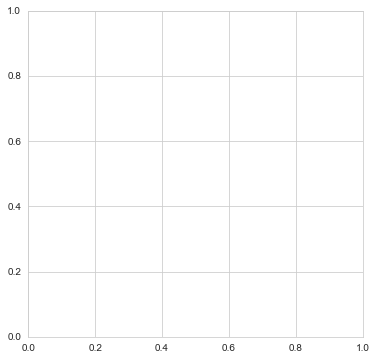

In [31]:
plt.subplots(figsize=(6,6))
sns.countplot(data=data, x = "Hotel", hue = 'Canceled', palette='rocket')
plt.title("Total Cancelations", fontsize=16)
plt.xlabel("Hotel", labelpad=15, fontsize=14)
plt.ylabel("Costumers", labelpad=15, fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(ncol=1, loc="upper right", frameon=False)
sns.despine(left=True, bottom=True)
plt.show()

In [32]:
ncanceled_counts = data['Canceled'].value_counts().No
canceled_counts = data['Canceled'].value_counts().Yes
perc_ncanceled = ncanceled_counts *100 / (ncanceled_counts + canceled_counts)
perc_canceled = canceled_counts *100 / (ncanceled_counts + canceled_counts)
print(f"Non-Canceled Booking: {ncanceled_counts}, {perc_ncanceled:.2f}%")
print(f"Canceled Booking: {canceled_counts}, {perc_canceled:.2f}%")

KeyError: 'Canceled'

In [33]:
data3 = data[data['Canceled']=='Yes']
canceled_month = data3['Arriving Month'].value_counts(normalize=True)*100
print("Cancelations by month [%]")
canceled_month

KeyError: 'Canceled'

There is a high indice of cancelations in City Hotel and Resort Hotel, most cancellations percentage are in high season. Number of cancelation in high season is obvously higher, but percentage distribution is not that big.

In [34]:
data3 = data[data['Canceled']=='Yes']
canceled_month = data3['Country'].value_counts(normalize=True)*100
print("Cancelations by country [%]")
typecanceled_month

KeyError: 'Canceled'

Natives( portugueses) tend to cancel much more than foreigners.

In [35]:
prev_cancel=data.loc[(data["Prev Cancel"] > 0)]
plt.subplots(figsize=(9,6))
sns.countplot(data=prev_cancel,x='Prev Cancel', hue="Canceled", palette= 'rocket')
plt.title("Total cancelation by number of previous cancelations", fontsize=16)
plt.xlabel("Number of previous cancelations", labelpad=15, fontsize=14)
plt.ylabel("Cancelations", labelpad=15, fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(ncol=1, loc="upper right", frameon=False)
sns.despine(left=True, bottom=True)
plt.show()

KeyError: 'Prev Cancel'

People who canceled the booking the first time tend to cancel the booking in perpetuity the next time.

In [36]:
deposit_ncanceled = data2.groupby(['Deposit Type']).agg("size")
deposit_canceled = data3.groupby(['Deposit Type']).agg("size")
pd.DataFrame({'Deposit':deposit_ncanceled.index, 'Not Canceled':deposit_ncanceled.values, 'Canceled':deposit_canceled.values})

NameError: name 'data2' is not defined

Most likely there is wrong information in this dataset. There is a preference for payments without an initial deposit, as expected, however there is a large number of cancellations with full deposits, which is completely unexpected... what is expected is that people who have fully or partially paid for their booking tend to cancel less.

In [37]:
#total cancelations by agent
agen_cancel = data3.groupby(['Hotel','Agent']).agg({'ADR': sum, 'People':sum, 'ADR per person': np.mean, 'Canceled':len})
agen_cancel.sort_values(by='People', ascending = False).head(20)
agen_cancel['Percentage'] = agen_cancel['Canceled'] *100 / canceled_counts
agen_cancel.sort_values(by='People', ascending = False).head(10)

NameError: name 'data3' is not defined

<font size="2"><b>Note:</b> Agent "0" is equal a no Agent.</font><br><br>

Agent id "9", "240" and "1" are the most profitable for the hotel and also have the highest rate of cancellations.

In [38]:
#total cancelations by company
agen_cancel = data3.groupby(['Hotel','Company']).agg({'ADR': sum, 'People':sum, 'ADR per person': np.mean, 'Canceled':len})
agen_cancel.sort_values(by='People', ascending = False).head(20)
agen_cancel['Percentage'] = agen_cancel['Canceled'] *100 / canceled_counts
agen_cancel.sort_values(by='People', ascending = False).head(10)

NameError: name 'data3' is not defined

<font size="2"><b>Note:</b> Company "0" is equal a no Company.</font><br><br>

97,33% of the cancelations coming from non-company.
Agents have much more influence on hotel billings than companies.

The exploratory data analysis stage is completed, there is much more to be analyzed about this dataset, but it would consume a lot of time and would not be so pleasant to read.

# Machine Learning Model

Machine learning, resumed, is a branch of artificial intelligence that is based on the idea that systems can learn from data, identify patterns and make decisions with little human intervention. Our goal is to create a machine learning model capable of predicting booking cancellations.

In [39]:
modify_data = data.copy()

<h2>Encoding</h2>

Machine Learning algorithms in general only accept numerical values, enconde is about convert categorical labels into numerical ones.

In [40]:
modify_data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [41]:
modify_data.shape

(119390, 32)

In [42]:
le = LabelEncoder()
modify_data['Canceled'] = le.fit_transform(modify_data['Canceled'])
modify_data["Country"] = [0 if i =='PRT' else 1 for i in modify_data["Country"]] # native or foreigner
modify_data["Prev Cancel"] = [0 if i == 0 else 1 for i in modify_data["Prev Cancel"]] # not cancel once or cancel at least once
modify_data["Company"] = [0 if i == 0 else 1 for i in modify_data["Company"]] # do not have a Company or have a Company

#Categorical Columns
categorical_features = ['Hotel', 'Meal', 'Country', 'Segment','Repeat Guest', 'Book Room Type', 'Customer Type'] #Canceled

#Numeric Columns
numerical_features = ['Lead Time', 'Arriving Week', 'Adults', "Children", 'Babies', "Repeat Guest", "Prev Cancel", 
               'Change Booking', "Agent", 'Company', 'ADR', 'Park Space', 'Special Request','Days Stay'] # Prev Cancel, Country

KeyError: 'Canceled'

In [43]:
##Drop Columns
drop_features = ['Arriving Year', 'Arriving Month', 'Arriving Day', 'Week Stay','Weekend Stay', 'Dist Channel', 'Prev Book', 
                  'Assign Room Type', 'Deposit Type', 'Waiting Days', 'Reservation Status', 'Reservation Date',
                  'ADR per person', 'People', 'Kids']

<h2>Dimensionality Reduction</h2>

The original dataset contains 32 features, many of then are not very useful for a predctive machine learning model. There are several approaches for reducing data dimensionality and selecting most useful features for machine learning model. This step is quite malleable and requires dozens of tests.

In [44]:
modify_data.corr()['Canceled'].abs().sort_values(ascending = False)

KeyError: 'Canceled'

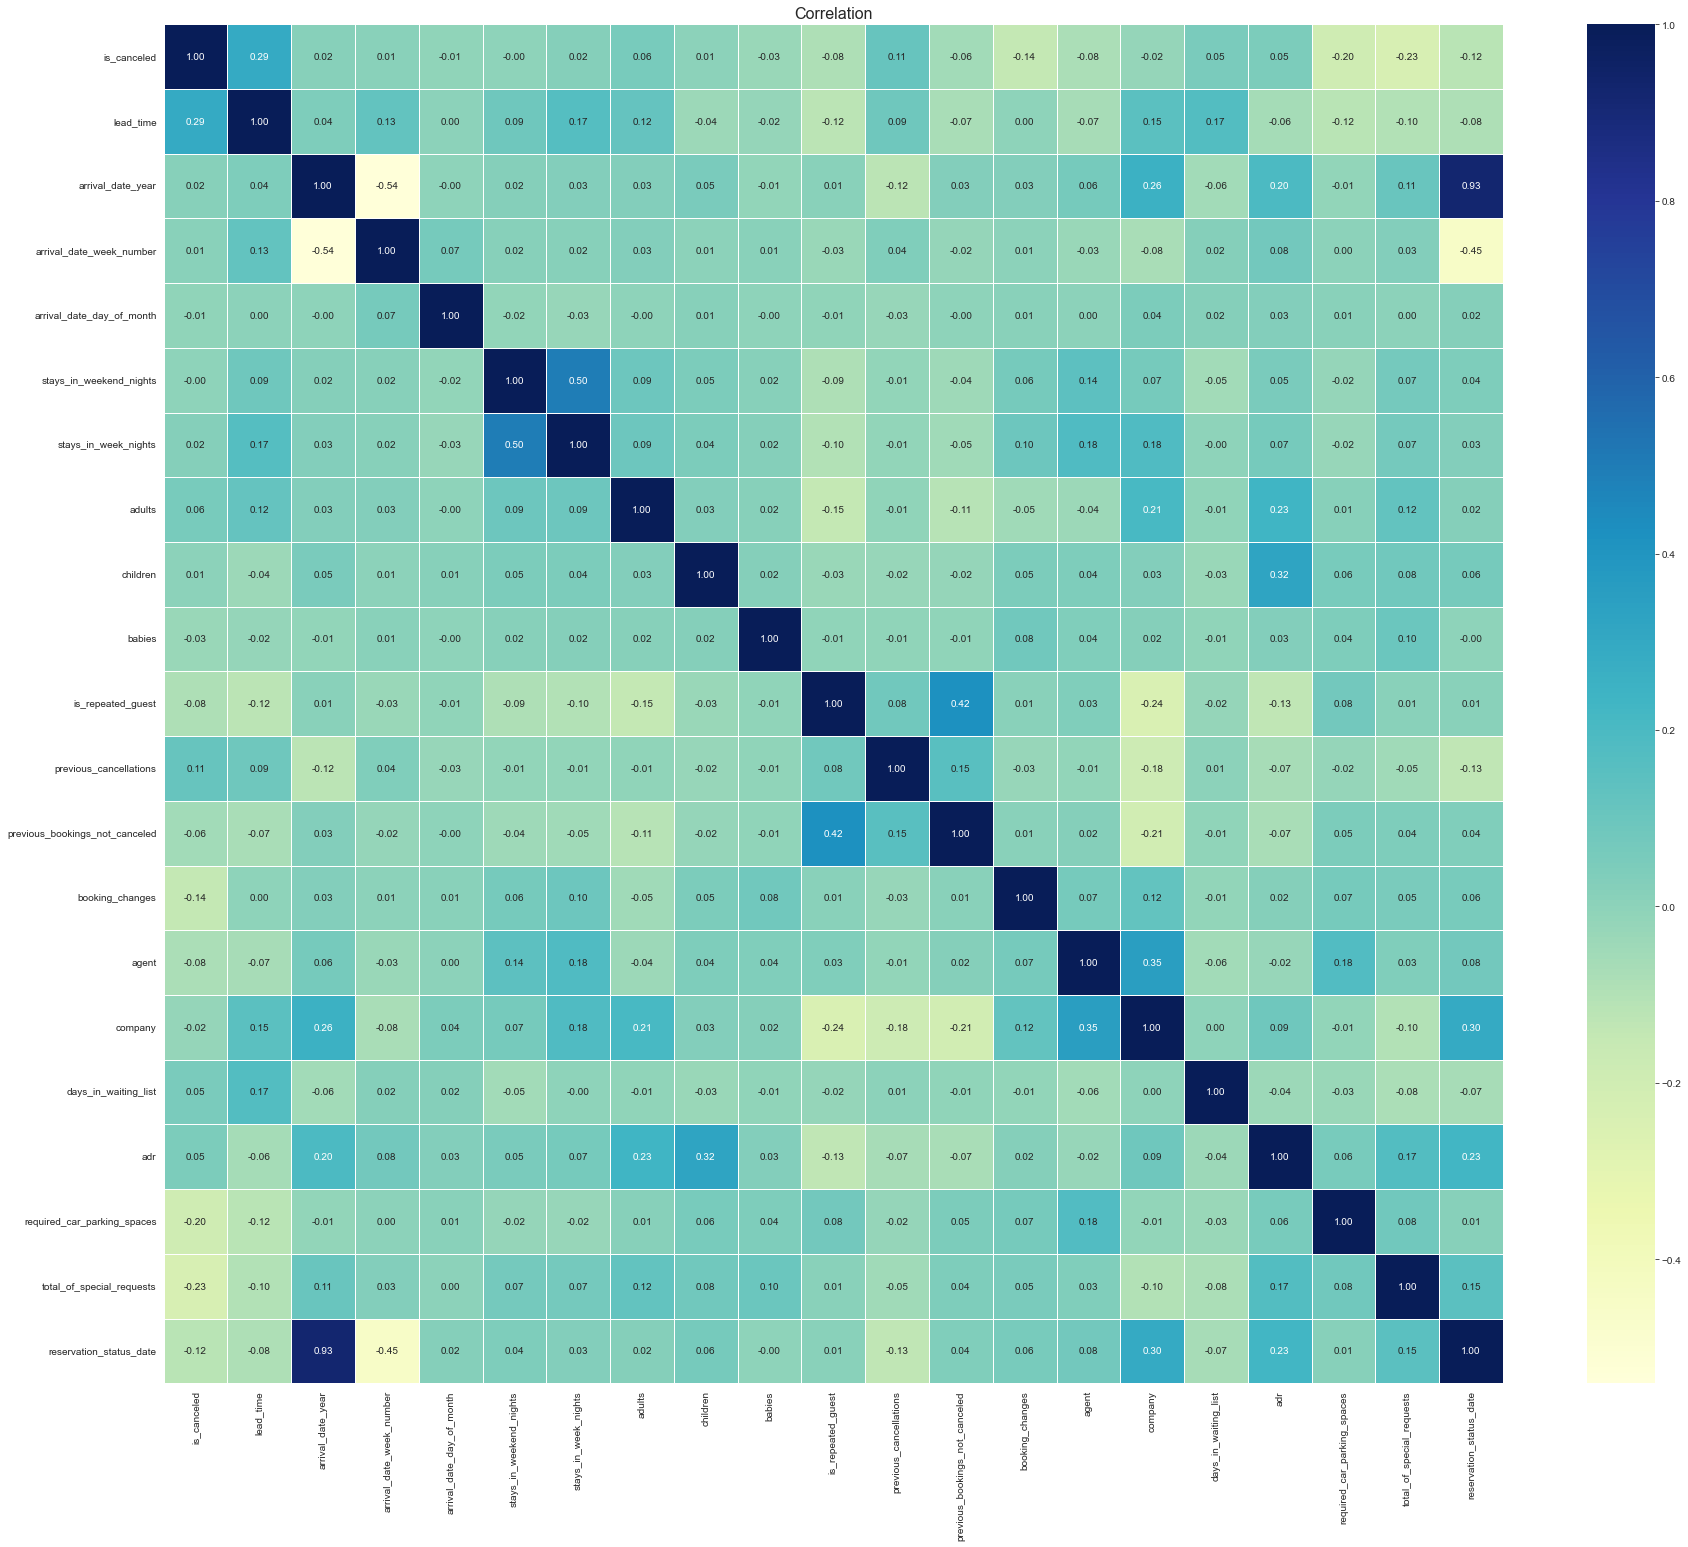

In [45]:
plt.figure(figsize=(30,25))
corr=modify_data.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='YlGnBu', linewidths=0.5)
plt.title("Correlation", fontsize=16)
plt.show()

<font size="4"><b><center>Very high/low correlation target (Cancelation)</center></b></font><br>
**Reservation Status:** Highly correlated with cancellation even because it has values that inform if the booking was cancelled also it is a bad feature for prediction.<br><br>

<font size="4"><b><center>Pairwise correlation</center></b></font><br>
**Assign Room Type / Book Room Type:** They are highly correlated pairwised, Assign Room Type also has low preditive power, bookings  different from the asigned are more related to face-to-face unforeseen.

**Market Segment / Dist Channel:** Most of the information contained in the Dist Channel is also contained in the Market Segment.

**Lead Time / Reservation Dates:**  Both gives a sense of position in time, from when booking we done to arrival. Due low variance they will probably be do not do any diference.

**Arriving Week / Arriving Month:** Both gives a sense of position in time... 

**Days Stay / (Week Stay, Weekend Stay):** "Week Stay" and "Week Stay" are strongly correlatade with Days Stay.

**People, Kids, ADR per person:** People, Kids, ADR per person can be easily expressed by other variables. They were useful for exploratory analysis, but here.

**Change Book / Prev Book:** Knowing the previous booking is not as relevant as know how many booking changes were made.<br><br><br>

<font size="4"><b><center>Missing/Wrong values</center></b></font> <br>
**Deposit Type:** As seen in the exploratory analysis, there is a good chance "Deposit Type" has wrong records, as changing them is infeasible, so it is better to exclude them. In a real world situation, the most correct would be to investigate what happened and adjust these values, because it is an important information to predict cancellations.<br><br>

<font size="4"><b><center>Low variance ratio:<center></b></font><br>
**Arriving Year:** there is nothing special in the years that explains the cancellation, also it is a bad feature for prediction.

In [46]:
#modify_data.drop(columns=drop_features, inplace=True)

<h2>Pipeline</h2>

The pipeline will consist of the standardization model (which makes the data at similar scales) and the machine learning models. As the data has already been processed there is no risk of the pipeline absorbing unwanted values

In [47]:
seed = 7

lr = LogisticRegression(random_state=seed)
rf = RandomForestClassifier(random_state=seed)
xgb = XGBClassifier(max_depth=4, min_child_weight = 1, gamma=0, random_state=seed)



selection = SelectPercentile(chi2, percentile=50)

preprocessor = ColumnTransformer(transformers=
    [
        ('std', MinMaxScaler(), numerical_features),
        ('ohe', OneHotEncoder(sparse=False, drop='if_binary', handle_unknown='ignore'), categorical_features),
        ('drop_features', 'drop', drop_features)
        
    ], remainder="drop"
)


pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor),
                              ('selection', selection),
              ('classifier', lr)
])


pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor),
                              ('selection', selection),
              ('classifier', rf)
])


pipeline_xgb = Pipeline(steps=[('preprocessor', preprocessor),
                               ('selection', selection),
              ('classifier', xgb)
                        
])

pipeline_lr

NameError: name 'numerical_features' is not defined

In [48]:
pipelines = [pipeline_lr, pipeline_rf, pipeline_xgb]
pipe_dict = {0:'Logistic Regression', 1:'Random Forest', 2:'XGBoost'}

NameError: name 'pipeline_lr' is not defined

In [95]:
y = modify_data["Canceled"]
X = modify_data.drop(["Canceled"], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, shuffle=True, random_state=7)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((83446, 35), (83446,), (35763, 35), (35763,))

<h2> Cross Validation</h2>

In [96]:
def CM(y_test, prediction):
    print("Confusion Matrix:")
    labels = ["Non-canceled", "Canceled"]
    cm = confusion_matrix(y_test, prediction)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="binary", values_format="d")  
    plt.show() 

In [97]:
number_folds = 4
Kfold = KFold(n_splits=number_folds, shuffle=True, random_state=seed)

*****************************************************
Machine Learning algorithm: Logistic Regression
*****************************************************


Confusion Matrix:


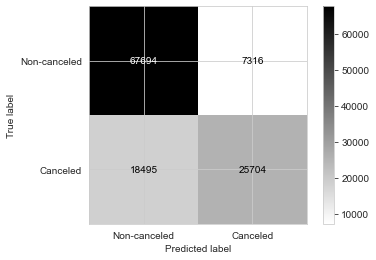



Accuracy: 0.7835 +/- 0.0029
Precision: 0.7784 +/- 0.0009
Recall: 0.5816 +/- 0.0068
F1 Score: 0.6657 +/- 0.0046
MSE: 0.2165 +/- 0.0029


*****************************************************
Machine Learning algorithm: Random Forest
*****************************************************


Confusion Matrix:


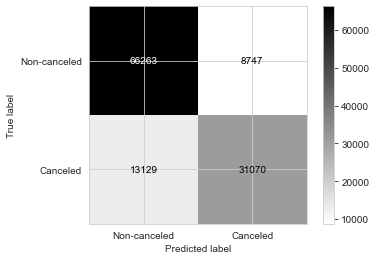



Accuracy: 0.8165 +/- 0.0026
Precision: 0.7803 +/- 0.0057
Recall: 0.7030 +/- 0.0035
F1 Score: 0.7396 +/- 0.0039
MSE: 0.1835 +/- 0.0026


*****************************************************
Machine Learning algorithm: XGBoost
*****************************************************


Confusion Matrix:


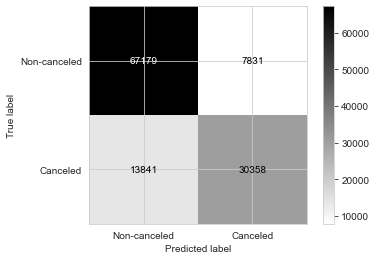



Accuracy: 0.8182 +/- 0.0029
Precision: 0.7950 +/- 0.0066
Recall: 0.6869 +/- 0.0044
F1 Score: 0.7370 +/- 0.0033
MSE: 0.1818 +/- 0.0029


Wall time: 58.5 s


In [98]:
%%time

np.random.seed(7)

score_metrics_cv = pd.DataFrame(columns=['Method','Accuracy','Precision','Recall','F1 Score','MSE'])

for i,model in enumerate(pipelines): 
    print('*' * 53) 
    print(f"Machine Learning algorithm: {pipe_dict[i]}") 
    print('*' * 53)     
    y_pred = cross_val_predict(model, X, y, cv=Kfold)
    print("\n")      
    CM(y,y_pred) 
    print("\n") 
   
    scores = cross_validate(model, X, y, cv = Kfold, scoring=("accuracy", "precision", "recall","f1","neg_mean_squared_error"))

    print(f"Accuracy: {scores['test_accuracy'].mean():.4f} +/- {scores['test_accuracy'].std():.4f}")
    print(f"Precision: {scores['test_precision'].mean():.4f} +/- {scores['test_precision'].std():.4f}")
    print(f"Recall: {scores['test_recall'].mean():.4f} +/- {scores['test_recall'].std():.4f}")
    print(f"F1 Score: {scores['test_f1'].mean():.4f} +/- {scores['test_f1'].std():.4f}")
    print(f"MSE: {scores['test_neg_mean_squared_error'].mean()*-1:.4f} +/- {scores['test_neg_mean_squared_error'].std():.4f}")
    print("\n")
    
    score_metrics_cv.loc[i] = (pipe_dict[i], scores['test_accuracy'].mean(), scores['test_precision'].mean(), scores['test_recall'].mean(), scores['test_f1'].mean(), scores['test_neg_mean_squared_error'].mean()*-1)    

In [99]:
pd.options.display.float_format = '{:,.4f}'.format
display("Cross Validation Scores",score_metrics_cv)

'Cross Validation Scores'

,Method,Accuracy,Precision,Recall,F1 Score,MSE
0,Logistic Regression,0.7835,0.7784,0.5816,0.6657,0.2165
1,Random Forest,0.8165,0.7803,0.7030,0.7396,0.1835
2,XGBoost,0.8182,0.7950,0.6869,0.7370,0.1818


<h2> ROC and AUC</h2>

ROC / AUC curve is parameterized curve use to evaluate the performance measurement for the classification problems at various threshold settings. ROC is a probability curve and AUC represents the degree or measure of separability. It tells how much the model is capable of distinguishing between classes. Higher the AUC, the better the model is at predicting 0 classes as 0 and 1 classes as 1.

*****************************************************
Machine Learning algorithm: Logistic Regression
*****************************************************


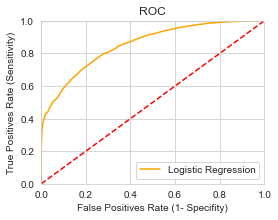

AUC Logistic Regression: 0.8524


*****************************************************
Machine Learning algorithm: Random Forest
*****************************************************


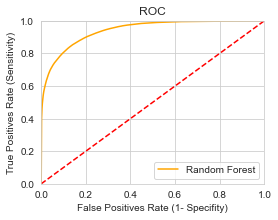

AUC Random Forest: 0.9400


*****************************************************
Machine Learning algorithm: XGBoost
*****************************************************


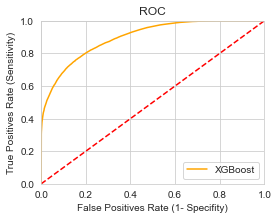

AUC XGBoost: 0.8973




In [100]:
score_metrics_auc = pd.DataFrame(columns=['Model','AUC'])

for i,model in enumerate(pipelines): 
    print('*' * 53) 
    print(f"Machine Learning algorithm: {pipe_dict[i]}") 
    print('*' * 53)   
    y_prob = model.fit(X_train,y_train)
    y_prob = model.predict_proba(X)
    y_prob = y_prob[:,1]
    
    fpr,tpr, threshold = roc_curve(y,y_prob)
    auc = roc_auc_score(y,y_prob)
    plt.figure(figsize=(4, 3))
    plt.plot(fpr,tpr, color='orange', label = pipe_dict[i])    
    plt.title("ROC")
    plt.xlim(0.0, 1.0)
    plt.ylim(0.0, 1.0)
    plt.plot([0,1],[0,1], color='red', linestyle='--')
    plt.xlabel("False Positives Rate (1- Specifity)")
    plt.ylabel("True Positives Rate (Sensitivity)")
    plt.legend(loc = 'lower right') 
    plt.show()
    print(f"AUC {pipe_dict[i]}: {auc:.4f}\n\n") 
    
    score_metrics_auc.loc[i]=[pipe_dict[i], auc]

In [101]:
score_metrics_cv['AUC'] = score_metrics_auc['AUC']
score_metrics_cv

,Method,Accuracy,Precision,Recall,F1 Score,MSE,AUC
0,Logistic Regression,0.7835,0.7784,0.5816,0.6657,0.2165,0.8524
1,Random Forest,0.8165,0.7803,0.7030,0.7396,0.1835,0.9400
2,XGBoost,0.8182,0.7950,0.6869,0.7370,0.1818,0.8973


<font size="3"><b>Which metric(s) should we adopt for the model?</b></font>

This is a hard question to answer. The data is a little unbalanced, approximately 1/3 of the guests are canceled, so the model has a better chance of getting a prediction right if it said opposite, there are data balance algorithms that i preferred not to address in this kernel that would improve this. Arbitrarily will be adopted "precision".

<h2>Hyperparamters Tunning</h2><br>
Hyperparameters are variables that control the training process itself. These variables are not directly related to the training data, they are configuration variables. 

Gridsearch literally try every possibility combination of hyperparametres over N number of  cross validation. This process this process can take minutes, hours, days depending on the settings made, below some hyperparameters settings will be made for didactic purposes, this step requires a high computational cost so there will be few configured. I'm not particularly interested in testing which are the best parameters in fact, just testing gridsearch functioning with pipelines.

In [30]:
%%time
### Tunning parameters: Logistic Regression ###

np.random.seed(7)

params1 = { 
        'preprocessor__std':[StandardScaler(), MinMaxScaler()],
        'selection':[SelectPercentile(chi2, percentile=50), PCA(n_components=10)],
       # 'classifier__C': [0.1,1,10], 
        'classifier__solver': ['lbfgs','saga'] 
        #'classifier__penalty': ['l1','l2']
        
}


params1['classifier'] = [lr] 


gs = GridSearchCV(pipeline_lr, params1, cv=Kfold, scoring='precision',verbose=True, n_jobs =-1, return_train_score=False)
gs.fit(X_train,y_train)

lr_tuning_score = gs.best_score_

print(f"\nPrecision Best Score:{gs.best_score_}") 
print(f"\nBest Paramters:\n{gs.best_params_}") 
print(f"\nBest Estimator:\n{gs.best_estimator_}") 

NameError: name 'lr' is not defined

In [115]:
%%time
### Tunning parameters: Random Forest

np.random.seed(7)

params2 = { 
        'preprocessor__numerical_transformer__std' : [StandardScaler(), MinMaxScaler()],
       # 'classifier__criterion' : ['gini', 'entropy']
       # 'classifier__max_depth': [1, 5],
       # 'classifier__n_estimators' : [200,400]
        # 'classifier__min_samples_leaf' : [1, 3, 5]
       
}

params2['classifier'] = [rf]

gs = GridSearchCV(estimator=pipeline_rf, param_grid=params2, cv=Kfold, scoring="precision", verbose=True, n_jobs =-1, return_train_score=False)
gs.fit(X_train,y_train)

rt_tuning_score = gs.best_score_

print(f"\nPrecision Best Score:{gs.best_score_}") 
print(f"\nBest Paramters:\n{gs.best_params_}") 
print(f"\nBest Estimator:\n{gs.best_estimator_}") 

Fitting 4 folds for each of 2 candidates, totalling 8 fits


ValueError: Invalid parameter numerical_transformer for estimator ColumnTransformer(transformers=[('std', MinMaxScaler(),
                                 ['Lead Time', 'Arriving Week', 'Adults',
                                  'Children', 'Babies', 'Repeat Guest',
                                  'Prev Cancel', 'Change Booking', 'Agent',
                                  'Company', 'ADR', 'Park Space',
                                  'Special Request', 'Days Stay']),
                                ('ohe',
                                 OneHotEncoder(drop='if_binary',
                                               handle_unknown='ignore',
                                               sparse=False),
                                 ['Hotel', 'Meal', 'Country', 'Segment',
                                  'Repeat Guest', 'Book Room Type',
                                  'Customer Type']),
                                ('drop_features', 'drop',
                               

In [1]:
%%time
### Tunning parameters: XGBoost

np.random.seed(7)

params3 = { 
        'preprocessor__numerical_transformer__std' : [StandardScaler(), MinMaxScaler()]
         #'classifier__max_depth': [3, 6]
         #'classifier__eta' : [0.1, 0.3]
        
}

params3['classifier'] = [xgb]

gs = GridSearchCV(estimator=pipeline_xgb, param_grid=params3, cv=Kfold, scoring="precision", verbose=True, n_jobs =-1, return_train_score=False)
gs.fit(X_train,y_train)

xgb_tuning_score = gs.best_score_

print(f"\nPrecision Best Score:{gs.best_score_}") 
print(f"\nBest Paramters:\n{gs.best_params_}") 
print(f"\nBest Estimator:\n{gs.best_estimator_}") 

NameError: name 'np' is not defined

In [116]:
%%time

### Tunning parameters: Global Gridsearch

np.random.seed(7)

params = [params1, params2, params3]

gs = GridSearchCV(estimator=pipeline_lr, param_grid=params, cv=Kfold, scoring="precision", verbose=True, n_jobs =-1)
gs.fit(X_train,y_train)

print(f"\nPrecision Best Score:{gs.best_score_}") 
print(f"\nBest Paramters:\n{gs.best_params_}") 
print(f"\nBest Estimator:\n{gs.best_estimator_}") 

Fitting 4 folds for each of 12 candidates, totalling 48 fits


ValueError: Invalid parameter numerical_transformer for estimator ColumnTransformer(transformers=[('std', MinMaxScaler(),
                                 ['Lead Time', 'Arriving Week', 'Adults',
                                  'Children', 'Babies', 'Repeat Guest',
                                  'Prev Cancel', 'Change Booking', 'Agent',
                                  'Company', 'ADR', 'Park Space',
                                  'Special Request', 'Days Stay']),
                                ('ohe',
                                 OneHotEncoder(drop='if_binary',
                                               handle_unknown='ignore',
                                               sparse=False),
                                 ['Hotel', 'Meal', 'Country', 'Segment',
                                  'Repeat Guest', 'Book Room Type',
                                  'Customer Type']),
                                ('drop_features', 'drop',
                               

In [109]:
score_metrics_cv ['Precision Tunning'] = [lr_tuning_score, rt_tuning_score,  xgb_tuning_score]
score_metrics_cv

NameError: name 'rt_tuning_score' is not defined

In [111]:
pickle.dump (model , open('C:\\Users\\Alysson\\Documents\\Projects\\Hotel Booking\hotel_booking.pkl','wb'))

# Conclusions


As we do not have detailed information about the hotel, some inferences end up becoming very generic, but in any case we will bring some insights into the business of this hotel: The City Hotel and Resort Hotel strangely receives few kids, so the hotel promoting more attractives for children might be a good idea, guests with children spends more. Some rooms are underused, the most sought room by far was A, other rooms could be more publicized or offer more attractive. There are Low rate of return of guests, it would be interesting for the hotel to offer better prices for repeat customers.


From the EDA the dataset has some confusing information about Deposit Type and ADR that could be usefull for our machine learnning model. Personally before studying this dataset, I could not imagine that the cancellation rate of booking was so high and this is certainly very problematic for hotels.

Random Forest Classifier and XGBoost Classifier provides better predict results. 


What is possible to implement that I find interesting, is the Ordinal Encoder for some variables like "Meal" and rank agents and companies( make a formula that takes for example the number of customers and adr), put other models, implement others methods for feature selection, using basyesian for search hyperparamters. 

I started to study data sciency just over a month, so many of the techniques and best procedures to be used I still haven't mastered. There are several things that can be improve/implement, so few free to suggest or criticize something.

If this helped in your learning, then please UPVOTE, thanks!